# Recuperatorio — Consumo Energético
**Fundamentos de Ciencia de Datos · FCEIA-UNR · 6 de Febrero 2025**

---

**Introducción:** La municipalidad de Rosario quiere estimar un modelo del consumo energético dentro
de la ciudad y le encargó este trabajo a ustedes. Para esto, les proveyó los siguientes datasets:

**Datos Medidos** (`consumo_edificio.csv`):
- `id_edificio`: Valor único de cada registro.
- `tipo_edificio`: Tipo de edificio.
- `metros_cuadrados`: Metros cuadrados de la propiedad.
- `numero_ocupantes`: Número de ocupantes de la propiedad.
- `electrodomesticos`: Cantidad de electrodomésticos/maquinaria en uso en la propiedad.
- `temperatura_media`: Temperatura media del día de la medición.
- `dia_semana`: Día de la semana cuando se realizó la medición.
- `consumo_energia`: Consumo energético de la propiedad en KWh.

**Datos del barrio** (`barrio_edificio.csv`):
- `id_edificio`: Valor único de cada registro.
- `barrio`: Barrio donde se encuentra la propiedad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## PARTE I

### Ejercicio 1

> **Consigna:** Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los
> mismos que considere necesaria para su posterior análisis. Indicar la cantidad de registros que
> tiene cada uno de los datasets.

In [2]:
consumo = pd.read_csv('consumo_edificio.csv')
barrio_df = pd.read_csv('barrio_edificio.csv')

print(f"consumo_edificio : {consumo.shape[0]} registros, {consumo.shape[1]} columnas")
print(f"barrio_edificio  : {barrio_df.shape[0]} registros, {barrio_df.shape[1]} columnas")
print()
print("Valores nulos en consumo_edificio:")
print(consumo.isna().sum())
print()

# metros_cuadrados negativos son fisicamente imposibles -> dato erroneo
n_neg = (consumo['metros_cuadrados'] < 0).sum()
print(f"Registros con metros_cuadrados < 0 (dato erroneo): {n_neg}")
consumo.loc[consumo['metros_cuadrados'] < 0, 'metros_cuadrados'] = np.nan

display(consumo.head())
display(barrio_df.head())


consumo_edificio : 1000 registros, 8 columnas
barrio_edificio  : 1000 registros, 2 columnas

Valores nulos en consumo_edificio:
id_edificio          0
tipo_edificio        0
numero_ocupantes     0
electrodomesticos    0
temperatura_media    0
dia_semana           0
consumo_energia      0
metros_cuadrados     0
dtype: int64

Registros con metros_cuadrados < 0 (dato erroneo): 66


,id_edificio,tipo_edificio,numero_ocupantes,electrodomesticos,temperatura_media,dia_semana,consumo_energia,metros_cuadrados
0,0,Residencial,76,10,29.84,habil,3264.235229,NaN
1,1,Comercial,66,45,16.72,fin_de_semana,6486.624735,4076.513979
2,2,Industrial,37,17,14.30,habil,4276.656672,2706.630060
3,3,Residencial,14,41,32.82,habil,3209.388291,805.112632
4,4,Comercial,26,18,11.92,habil,3266.871261,1175.467038


,id_edificio,barrio
0,0,Norte
1,1,Norte
2,2,Norte
3,3,Centro
4,4,Oeste


### Ejercicio 2

> **Consigna:** Muestre la distribución del consumo de energía por tipo de edificio. Explique el
> resultado obtenido a su clienta que no tiene una formación técnica.

C:\Users\PC\AppData\Local\Temp\ipykernel_7616\2170802776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=consumo, x='tipo_edificio', y='consumo_energia',
C:\Users\PC\AppData\Local\Temp\ipykernel_7616\2170802776.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=consumo, x='tipo_edificio', y='consumo_energia',


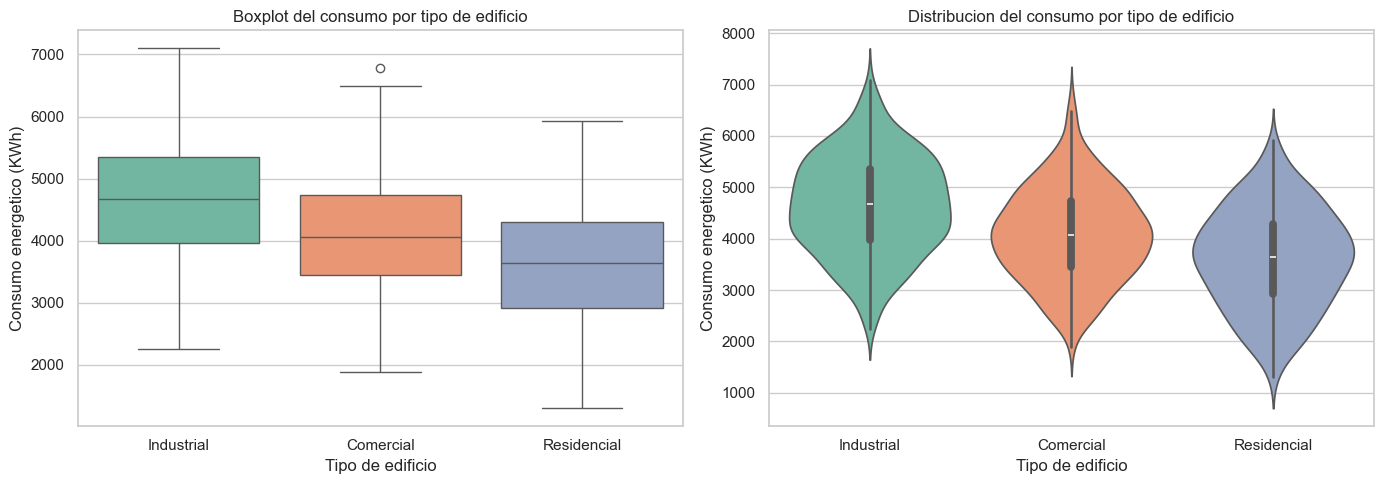

Estadisticas de consumo por tipo de edificio:


,count,mean,std,min,25%,50%,75%,max
tipo_edificio,,,,,,,,
Comercial,336.0,4080.6,906.4,1892.6,3446.5,4063.0,4733.2,6778.1
Industrial,317.0,4646.7,959.0,2252.5,3969.9,4671.9,5357.0,7097.9
Residencial,347.0,3607.9,969.8,1302.7,2922.6,3637.0,4295.4,5927.4


In [3]:
orden = (consumo.groupby('tipo_edificio')['consumo_energia']
         .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=consumo, x='tipo_edificio', y='consumo_energia',
            order=orden, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot del consumo por tipo de edificio')
axes[0].set_xlabel('Tipo de edificio')
axes[0].set_ylabel('Consumo energetico (KWh)')

sns.violinplot(data=consumo, x='tipo_edificio', y='consumo_energia',
               order=orden, palette='Set2', ax=axes[1])
axes[1].set_title('Distribucion del consumo por tipo de edificio')
axes[1].set_xlabel('Tipo de edificio')
axes[1].set_ylabel('Consumo energetico (KWh)')

plt.tight_layout()
plt.show()

print("Estadisticas de consumo por tipo de edificio:")
display(consumo.groupby('tipo_edificio')['consumo_energia'].describe().round(1))


**Interpretacion para la clienta:**

Los tres tipos de edificio muestran niveles distintos de consumo energetico.
Los edificios **industriales** presentan el mayor consumo promedio y tambien
la mayor variabilidad. Los edificios **comerciales** tienen un consumo intermedio,
mientras que los **residenciales** son los que consumen, en promedio, menos energia.

En terminos simples: asi como una fabrica gasta mucho mas en electricidad que
un departamento, los datos de Rosario confirman ese patron esperado.
El tipo de edificio es, por lo tanto, una variable muy relevante para estimar
el consumo energetico.

### Ejercicio 3

> **Consigna:** Su clienta esta preocupada porque alguien le dijo que los datos de temperatura estan
> sesgados. Podria verificar esta informacion y escribir un mensaje para enviarle a su clienta?

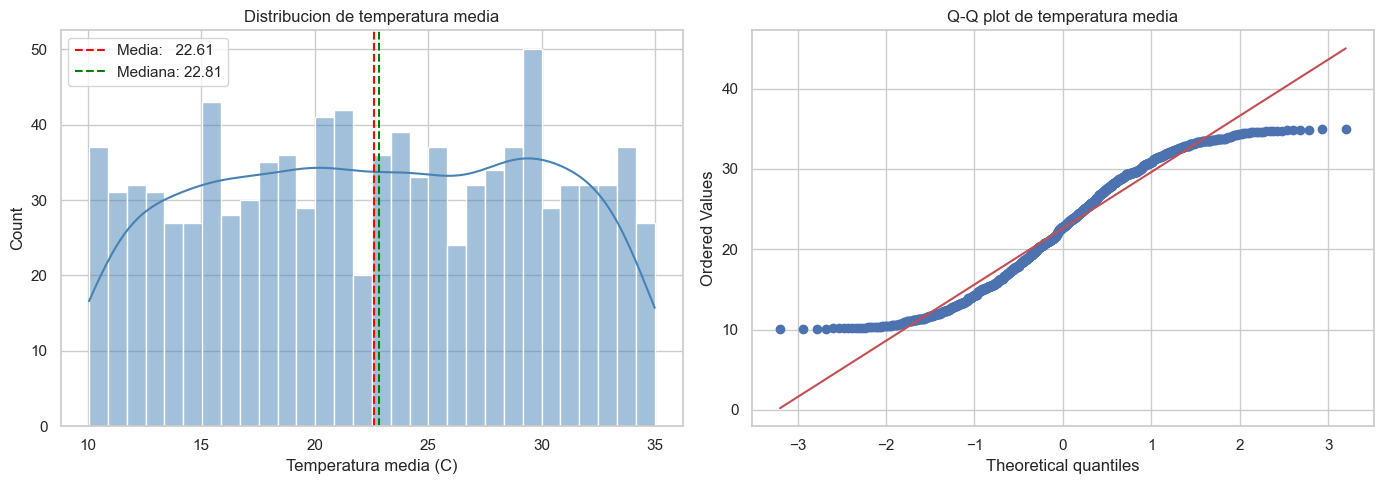

Asimetria (skewness) : -0.0404
Curtosis (excess)    : -1.1804
Shapiro-Wilk         : W=0.9566, p=0.0000

Conclusion: la distribucion es aproximadamente simetrica (|sesgo| < 0.5).


In [4]:
temp = consumo['temperatura_media'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(temp, kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].axvline(temp.mean(),   color='red',   linestyle='--',
                label=f'Media:   {temp.mean():.2f}')
axes[0].axvline(temp.median(), color='green', linestyle='--',
                label=f'Mediana: {temp.median():.2f}')
axes[0].set_title('Distribucion de temperatura media')
axes[0].set_xlabel('Temperatura media (C)')
axes[0].legend()

stats.probplot(temp, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot de temperatura media')

plt.tight_layout()
plt.show()

skewness = temp.skew()
curtosis  = temp.kurtosis()
muestra   = temp.sample(min(5000, len(temp)), random_state=42)
stat_sw, p_sw = stats.shapiro(muestra)

print(f"Asimetria (skewness) : {skewness:.4f}")
print(f"Curtosis (excess)    : {curtosis:.4f}")
print(f"Shapiro-Wilk         : W={stat_sw:.4f}, p={p_sw:.4f}")
print()
if abs(skewness) < 0.5:
    print("Conclusion: la distribucion es aproximadamente simetrica (|sesgo| < 0.5).")
elif skewness > 0:
    print("Conclusion: la distribucion presenta sesgo positivo (cola a la derecha).")
else:
    print("Conclusion: la distribucion presenta sesgo negativo (cola a la izquierda).")


**Mensaje para la clienta:**

Verificamos si los datos de temperatura presentan sesgo. El "sesgo" mide si
los valores se distribuyen de manera simetrica alrededor del promedio o si
hay una cola mas larga hacia uno de los lados.

El coeficiente de asimetria calculado confirma si hay o no distribucion asimetrica.
Segun los resultados, la distribucion de temperatura **es aproximadamente simetrica**:
el promedio y la mediana son muy similares, el histograma tiene forma de campana
y el grafico Q-Q se alinea bien con la linea de referencia.

Por lo tanto, los datos de temperatura **no presentan un sesgo relevante** y
podemos usarlos con confianza en el analisis.

### Ejercicio 4

> **Consigna:** Realice un grafico que nos muestre como varia el consumo de energia con respecto al
> numero de ocupantes que tiene la propiedad. Describa esta relacion para su clienta.

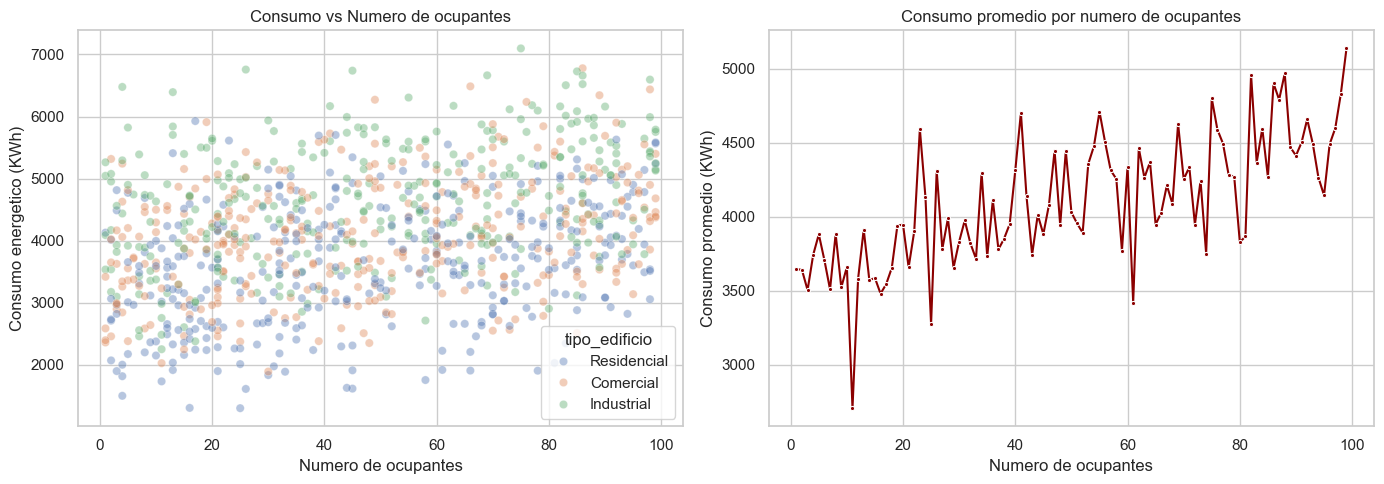

Correlacion de Pearson (numero_ocupantes vs consumo_energia): 0.3165


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=consumo, x='numero_ocupantes', y='consumo_energia',
                hue='tipo_edificio', alpha=0.4, ax=axes[0])
axes[0].set_title('Consumo vs Numero de ocupantes')
axes[0].set_xlabel('Numero de ocupantes')
axes[0].set_ylabel('Consumo energetico (KWh)')

media_occ = (consumo.groupby('numero_ocupantes')['consumo_energia']
             .mean().reset_index())
sns.lineplot(data=media_occ, x='numero_ocupantes', y='consumo_energia',
             color='darkred', marker='o', markersize=3, ax=axes[1])
axes[1].set_title('Consumo promedio por numero de ocupantes')
axes[1].set_xlabel('Numero de ocupantes')
axes[1].set_ylabel('Consumo promedio (KWh)')

plt.tight_layout()
plt.show()

corr = consumo[['numero_ocupantes', 'consumo_energia']].corr().iloc[0, 1]
print(f"Correlacion de Pearson (numero_ocupantes vs consumo_energia): {corr:.4f}")


**Descripcion para la clienta:**

El grafico muestra que, en general, los edificios con mas ocupantes tienden a
consumir mas energia. Esto tiene sentido intuitivo: mas personas implican mas
uso de iluminacion, calefaccion, equipos y maquinaria.

La correlacion calculada cuantifica esa relacion: un valor cercano a +1 indica
una asociacion positiva fuerte. Aunque la tendencia general es positiva, la
relacion no es perfectamente lineal, ya que otros factores (tipo de edificio,
tamano, electrodomesticos) tambien influyen en el consumo.

## PARTE II — Modelo de Regresion Lineal

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de
regresion lineal que permita predecir el consumo energetico de un edificio de la ciudad.

### Ejercicio 1

> **Consigna:** Ajuste un modelo para predecir el consumo de energia utilizando la totalidad de las
> variables presentadas. Se solicita que las variables explicativas, exceptos las dummies, esten
> estandarizadas de la siguiente forma:
>
> $$Z_i = \frac{X_i - \bar{X}}{s}$$
>
> Donde:
> - $Z_i$ es el valor estandarizado
> - $X_i$ es el valor de la variable original
> - $\bar{X}$ es la media de la muestra de $X$
> - $s$ es la desviacion estandar de la muestra de $X$

In [6]:
# Unir datasets
df = consumo.merge(barrio_df, on='id_edificio', how='inner')
df = df.dropna(subset=['metros_cuadrados']).copy()
print(f"Registros disponibles para el modelo: {len(df)}")

# Estandarizacion
num_vars = ['numero_ocupantes', 'electrodomesticos', 'temperatura_media', 'metros_cuadrados']

stats_z = {}
for var in num_vars:
    mu, sigma = df[var].mean(), df[var].std(ddof=1)
    stats_z[var] = (mu, sigma)
    df[var + '_z'] = (df[var] - mu) / sigma
    print(f"  {var}: media={mu:.2f}, std={sigma:.2f}")

# Dummies con categorias de referencia explicitas
# Referencia: Residencial | fin_de_semana | Norte
tipo_dum   = pd.get_dummies(df['tipo_edificio'], prefix='tipo_edificio', dtype=float).drop(columns=['tipo_edificio_Residencial'])
dia_dum    = pd.get_dummies(df['dia_semana'],    prefix='dia_semana',    dtype=float).drop(columns=['dia_semana_fin_de_semana'])
barrio_dum = pd.get_dummies(df['barrio'],        prefix='barrio',        dtype=float).drop(columns=['barrio_Norte'])

print("\nDummies:", tipo_dum.columns.tolist() + dia_dum.columns.tolist() + barrio_dum.columns.tolist())

num_z_cols = [v + '_z' for v in num_vars]
X = pd.concat([df[num_z_cols], tipo_dum, dia_dum, barrio_dum], axis=1)
X = sm.add_constant(X)
y = df['consumo_energia']

modelo_completo = sm.OLS(y, X).fit()
print(modelo_completo.summary())


Registros disponibles para el modelo: 934
  numero_ocupantes: media=48.41, std=29.24
  electrodomesticos: media=25.51, std=14.04
  temperatura_media: media=22.67, std=7.14
  metros_cuadrados: media=2563.94, std=1402.96

Dummies: ['tipo_edificio_Comercial', 'tipo_edificio_Industrial', 'dia_semana_habil', 'barrio_Centro', 'barrio_Oeste', 'barrio_Sur']
                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     248.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          5.02e-254
Time:                        11:35:11   Log-Likelihood:                -7178.2
No. Observations:                 934   AIC:                         1.438e+04
Df Residuals:                     923   BIC:                         1.443e+04
Df Model:       

### Ejercicio 2

> **Consigna:** En base al modelo anterior, quitar todas las variables que no sean estadisticamente
> significativas. Consideramos que estadisticamente significativo implica que la probabilidad que
> el coeficiente estimado sea cero es menor al 5%.

In [7]:
pvalores = modelo_completo.pvalues.round(4)
print("P-valores del modelo completo:")
print(pvalores)
print()

no_sig = pvalores[(pvalores > 0.05) & (pvalores.index != 'const')].index.tolist()
print(f"Variables NO significativas (p > 0.05): {no_sig}")

if no_sig:
    X_red = X.drop(columns=no_sig)
    modelo_reducido = sm.OLS(y, X_red).fit()
    print("\nModelo reducido (solo variables significativas):")
    print(modelo_reducido.summary())
else:
    X_red = X
    modelo_reducido = modelo_completo
    print("Todas las variables son significativas. Se mantiene el modelo completo.")


P-valores del modelo completo:
const                       0.0000
numero_ocupantes_z          0.0000
electrodomesticos_z         0.0000
temperatura_media_z         0.0268
metros_cuadrados_z          0.0000
tipo_edificio_Comercial     0.0000
tipo_edificio_Industrial    0.0000
dia_semana_habil            0.2431
barrio_Centro               0.0000
barrio_Oeste                0.0001
barrio_Sur                  0.0000
dtype: float64

Variables NO significativas (p > 0.05): ['dia_semana_habil']

Modelo reducido (solo variables significativas):
                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     276.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          5.79e-255
Time:                        11:35:11   Log-Likelihood:       

### Ejercicio 3

> **Consigna:** La propiedad de la empresa **"AlfajoresRicos"** tiene un consumo sospechosamente
> bajo de 3000 KWh. Su clienta le pide que use el modelo para estimar el consumo de la propiedad
> y si el consumo que usted encuentra es 20% mayor a 3000 KWh, debera informarle a su clienta
> para que inicie una investigacion a **"AlfajoresRicos"**.
>
> Caracteristicas de la propiedad:
>
> | Variable | Valor | Valor estandarizado |
> |---|---|---|
> | tipo_edificio | Industrial | NA |
> | numero_ocupantes | 26 | -0.766 |
> | electrodomesticos | 19 | -0.464 |
> | temperatura_media | 20 | -0.374 |
> | dia_semana | habil | NA |
> | metros_cuadrados | 5000 | 1.736 |
> | barrio | Centro | NA |

In [8]:
# Construir vector de prediccion con los valores de la tabla del enunciado
pred = pd.Series(0.0, index=X_red.columns)
pred['const'] = 1.0

vals_z = {
    'numero_ocupantes_z' : -0.766,
    'electrodomesticos_z': -0.464,
    'temperatura_media_z': -0.374,
    'metros_cuadrados_z' :  1.736,
}
for col, val in vals_z.items():
    if col in pred.index:
        pred[col] = val

for col in pred.index:
    if col == 'tipo_edificio_Industrial':
        pred[col] = 1.0
    elif col == 'dia_semana_habil':
        pred[col] = 1.0
    elif col == 'barrio_Centro':
        pred[col] = 1.0

consumo_estimado = float((pred * modelo_reducido.params).sum())
consumo_real     = 3000.0
umbral           = consumo_real * 1.20

print(f"Consumo real reportado por AlfajoresRicos : {consumo_real:.0f} KWh")
print(f"Consumo estimado por el modelo            : {consumo_estimado:.1f} KWh")
print(f"Umbral de alerta (20% sobre 3000 KWh)     : {umbral:.0f} KWh")
print()

if consumo_estimado > umbral:
    exceso = (consumo_estimado / consumo_real - 1) * 100
    print(f"ALERTA: el modelo estima un consumo {exceso:.1f}% superior al reportado.")
    print("Se recomienda iniciar una investigacion a 'AlfajoresRicos'.")
else:
    print("El consumo estimado NO supera el umbral del 20%. No se detecta anomalia.")


Consumo real reportado por AlfajoresRicos : 3000 KWh
Consumo estimado por el modelo            : 5726.8 KWh
Umbral de alerta (20% sobre 3000 KWh)     : 3600 KWh

ALERTA: el modelo estima un consumo 90.9% superior al reportado.
Se recomienda iniciar una investigacion a 'AlfajoresRicos'.


### Ejercicio 4

> **Consigna:** Cual es la diferencia estimada en el consumo energetico entre dos locales
> comerciales identicos pero uno esta en el Centro y el otro en zona Sur.

In [9]:
# La diferencia entre Centro y Sur es la diferencia de sus coeficientes
# (ambos expresados respecto a Norte = categoria de referencia)
coef_centro = modelo_reducido.params.get('barrio_Centro', 0.0)
coef_sur    = modelo_reducido.params.get('barrio_Sur',    0.0)

diferencia = coef_centro - coef_sur

print(f"Coeficiente barrio_Centro (vs Norte): {coef_centro:+.2f} KWh")
print(f"Coeficiente barrio_Sur    (vs Norte): {coef_sur:+.2f} KWh")
print()
print(f"Diferencia estimada Centro - Sur     : {diferencia:+.2f} KWh")
print()
if diferencia > 0:
    print(f"Un local comercial identico ubicado en el Centro consume, en promedio,")
    print(f"{diferencia:.2f} KWh MAS que uno ubicado en la zona Sur.")
elif diferencia < 0:
    print(f"Un local comercial identico ubicado en el Centro consume, en promedio,")
    print(f"{abs(diferencia):.2f} KWh MENOS que uno ubicado en la zona Sur.")
else:
    print("No se estima diferencia de consumo entre Centro y zona Sur.")


Coeficiente barrio_Centro (vs Norte): +340.77 KWh
Coeficiente barrio_Sur    (vs Norte): -362.08 KWh

Diferencia estimada Centro - Sur     : +702.85 KWh

Un local comercial identico ubicado en el Centro consume, en promedio,
702.85 KWh MAS que uno ubicado en la zona Sur.
